# Assignment 1 -- Train the Hierarchical VAE

In this assignment you will train the Conductor-Worker model on a category of your choice and evaluate how well the hierarchy helps compared to the baseline VAE from last week.

**What you need to submit:**
- Trained HierarchicalVAE on a non-cat category (20+ epochs)
- Loss curves
- Reconstruction grid (original vs reconstructed)
- Written comparison with the baseline VAE
- Answers to reflection questions

## Step 1 -- Load your category

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, json, os
import matplotlib.pyplot as plt
import urllib.request
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

category = 'bed'   # TODO: change to your category

# TODO: Paste drawing_to_stroke5, normalise_stroke5, QuickDrawDataset, collate_fn
# YOUR CODE HERE
def drawing_to_stroke5(drawing, max_len=200):
    strokes = []
    for stroke in drawing:
        xs, ys = stroke[0], stroke[1]
        for i in range(len(xs)):
            dx = xs[i] - xs[i-1] if i > 0 else 0
            dy = ys[i] - ys[i-1] if i > 0 else 0
            if i < len(xs) - 1: p1, p2, p3 = 1, 0, 0
            else: p1, p2, p3 = 0, 1, 0
            strokes.append([dx, dy, p1, p2, p3])
    strokes.append([0, 0, 0, 0, 1])
    s5 = np.array(strokes, dtype=np.float32)
    if len(s5) > max_len:
        s5 = s5[:max_len]; s5[-1] = [0, 0, 0, 0, 1]
    return s5

def normalise_stroke5(stroke5):
    s = stroke5.copy()
    coords = s[:, :2]
    s[:, :2] = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)
    return s

class QuickDrawDataset(Dataset):
    def __init__(self, path, max_len=200, max_samples=5000):
        self.samples = []
        with open(path) as f:
            for i, line in enumerate(f):
                if i >= max_samples: break
                d = json.loads(line)
                s5 = drawing_to_stroke5(d['drawing'], max_len=max_len)
                s5 = normalise_stroke5(s5)
                self.samples.append(torch.tensor(s5, dtype=torch.float32))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

def collate_fn(batch):
    lengths = [seq.shape[0] for seq in batch]
    padded  = pad_sequence(batch, batch_first=True, padding_value=0.0)
    return padded, lengths

# TODO: Load dataset and create DataLoader with batch_size=16
# YOUR CODE HERE
os.makedirs('data', exist_ok=True)
path = 'data/bed.ndjson'
if not os.path.exists(path):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/quickdraw_dataset/full/simplified/bed.ndjson', path)

dataset = QuickDrawDataset(path, max_len=200, max_samples=3000)
loader  = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
print('Setup complete. Dataset size:', len(dataset))


Setup complete. Dataset size: 3000


## Step 2 -- Define the Hierarchical VAE

Copy Encoder, Conductor, Worker, and HierarchicalVAE from the conductor_worker notebook.

In [2]:
# TODO: Paste all model definitions here
# YOUR CODE HERE
class Encoder(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256, latent_dim=128):
        super().__init__()
        self.lstm      = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_mu     = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[0], h[1]], dim=-1)
        return self.fc_mu(h), self.fc_logvar(h)

def reparameterise(mu, logvar):
    return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

# Test
encoder = Encoder(input_dim=5, hidden_dim=256, latent_dim=128)
padded, lengths = next(iter(loader))
mu, logvar = encoder(padded, lengths)
print('mu shape:', mu.shape)   # (batch, 128)

class Conductor(nn.Module):
    def __init__(self, latent_dim=128, conductor_dim=512, output_dim=256, num_segments=16):
        '''
        latent_dim    : size of z from the encoder
        conductor_dim : hidden size of the conductor LSTM
        output_dim    : size of each sub-goal vector c
        num_segments  : number of sub-goals to produce (U)
        '''
        super().__init__()
        self.num_segments = num_segments
        self.fc_init  = nn.Linear(latent_dim, conductor_dim)    # initialise hidden state from z
        self.lstm     = nn.LSTM(output_dim, conductor_dim, batch_first=True)
        self.fc_out   = nn.Linear(conductor_dim, output_dim)    # project to sub-goal size
        self.output_dim = output_dim

    def forward(self, z):
        '''
        z : latent vector shape (batch, latent_dim)

        Returns:
            c_seq : sub-goal sequence shape (batch, num_segments, output_dim)
        '''
        batch_size = z.shape[0]
        h = torch.tanh(self.fc_init(z)).unsqueeze(0)  # (1, batch, conductor_dim)
        c_cell = torch.zeros_like(h)

        # Start with a zero input token
        input_c = torch.zeros(batch_size, 1, self.output_dim, device=z.device)
        c_list  = []

        for _ in range(self.num_segments):
            out, (h, c_cell) = self.lstm(input_c, (h, c_cell))
            c = self.fc_out(out)   # (batch, 1, output_dim)
            c_list.append(c)
            input_c = c            # feed sub-goal back as next input

        return torch.cat(c_list, dim=1)   # (batch, num_segments, output_dim)

conductor = Conductor(latent_dim=128, conductor_dim=512, output_dim=256, num_segments=16)
z = reparameterise(mu, logvar)
c_seq = conductor(z)
print('Sub-goal sequence shape:', c_seq.shape)   # (batch, 16, 256)

class Worker(nn.Module):
    def __init__(self, input_dim=5, conductor_out_dim=256,
                 worker_dim=512, output_dim=5):
        '''
        input_dim         : stroke-5 input features
        conductor_out_dim : size of the sub-goal vector c from the Conductor
        worker_dim        : hidden size of the worker LSTM
        output_dim        : output features (5 for stroke-5)
        '''
        super().__init__()
        # Worker input = stroke step + sub-goal vector concatenated
        self.lstm   = nn.LSTM(input_dim + conductor_out_dim, worker_dim, batch_first=True)
        self.fc_out = nn.Linear(worker_dim, output_dim)

    def forward(self, stroke_seq, c_seq, segment_len):
        '''
        stroke_seq  : teacher-forced input strokes (batch, seq_len, 5)
        c_seq       : sub-goal sequence (batch, num_segments, conductor_out_dim)
        segment_len : how many steps each sub-goal covers

        Returns:
            output : predicted strokes (batch, seq_len, 5)
        '''
        batch_size, seq_len, _ = stroke_seq.shape
        num_segments = c_seq.shape[1]

        # Expand each sub-goal to cover segment_len steps
        # c_seq shape: (batch, num_segments, c_dim)
        # We repeat each c for segment_len steps then trim to seq_len
        c_expanded = c_seq.repeat_interleave(segment_len, dim=1)  # (batch, num_seg*seg_len, c_dim)
        c_expanded = c_expanded[:, :seq_len, :]                   # trim to actual seq_len

        # Concatenate stroke input with sub-goal at each step
        worker_input = torch.cat([stroke_seq, c_expanded], dim=-1)  # (batch, seq_len, 5+c_dim)

        output, _ = self.lstm(worker_input)
        return self.fc_out(output)   # (batch, seq_len, 5)

worker = Worker(input_dim=5, conductor_out_dim=256, worker_dim=512, output_dim=5)

# Prepare teacher-forced input (shift sequence right by 1)
start_token   = torch.zeros(padded.shape[0], 1, 5)
decoder_input = torch.cat([start_token, padded[:, :-1, :]], dim=1)

segment_len = padded.shape[1] // conductor.num_segments + 1
output = worker(decoder_input, c_seq, segment_len)
print('Worker output shape:', output.shape)   # (batch, seq_len, 5)

class HierarchicalVAE(nn.Module):
    def __init__(self,
                 input_dim=5,
                 encoder_hidden=256,
                 latent_dim=128,
                 conductor_dim=512,
                 conductor_out_dim=256,
                 num_segments=16,
                 worker_dim=512):
        super().__init__()
        self.num_segments     = num_segments
        self.conductor_out_dim = conductor_out_dim

        self.encoder   = Encoder(input_dim, encoder_hidden, latent_dim)
        self.conductor = Conductor(latent_dim, conductor_dim, conductor_out_dim, num_segments)
        self.worker    = Worker(input_dim, conductor_out_dim, worker_dim, input_dim)

    def forward(self, x, lengths):
        # Encode
        mu, logvar = self.encoder(x, lengths)
        z = reparameterise(mu, logvar)

        # Conductor produces sub-goals
        c_seq = self.conductor(z)

        # Teacher-forced worker input
        start_token   = torch.zeros(x.shape[0], 1, x.shape[2], device=x.device)
        decoder_input = torch.cat([start_token, x[:, :-1, :]], dim=1)

        segment_len = x.shape[1] // self.num_segments + 1
        output = self.worker(decoder_input, c_seq, segment_len)

        return output, mu, logvar

model = HierarchicalVAE()
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')

out, mu, logvar = model(padded, lengths)
print('Output shape:', out.shape)   # (batch, seq_len, 5)



mu shape: torch.Size([16, 128])
Sub-goal sequence shape: torch.Size([16, 16, 256])
Worker output shape: torch.Size([16, 74, 5])
Total parameters: 4,034,053
Output shape: torch.Size([16, 74, 5])


## Step 3 -- Train for 20+ epochs

In [3]:
# TODO: Training loop with KL annealing
# Store total, recon_pos, recon_pen, kl losses per epoch
# YOUR CODE HERE
def kl_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def hierarchical_loss(output, target, mu, logvar, kl_weight=0.5):
    # MSE on position
    recon_pos = F.mse_loss(output[:, :, :2], target[:, :, :2])
    # Cross entropy on pen state (p1, p2, p3)
    pen_pred   = output[:, :, 2:]
    pen_target = target[:, :, 2:].argmax(dim=-1)   # convert one-hot to class index
    recon_pen  = F.cross_entropy(
        pen_pred.reshape(-1, 3),
        pen_target.reshape(-1).long()
    )
    kl = kl_loss(mu, logvar)
    return recon_pos + recon_pen + kl_weight * kl, recon_pos, recon_pen, kl

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = HierarchicalVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
history    = {'total': [], 'recon_pos': [], 'recon_pen': [], 'kl': []}

for epoch in range(num_epochs):
    model.train()
    totals = {k: 0.0 for k in history}
    kl_weight = min(0.5, epoch / num_epochs)

    for padded, lengths in loader:
        padded = padded.to(device)
        output, mu, logvar = model(padded, lengths)
        loss, rp, rpen, kl = hierarchical_loss(output, padded, mu, logvar, kl_weight)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        totals['total']     += loss.item()
        totals['recon_pos'] += rp.item()
        totals['recon_pen'] += rpen.item()
        totals['kl']        += kl.item()

    n = len(loader)
    for k in history: history[k].append(totals[k] / n)
    print(f'Epoch {epoch+1:02d}/{num_epochs} | '
          f'loss {history["total"][-1]:.4f} | '
          f'recon_pos {history["recon_pos"][-1]:.4f} | '
          f'kl {history["kl"][-1]:.4f}')

torch.save(model.state_dict(), 'hierarchical_vae.pth')
print('Model saved.')


Epoch 01/20 | loss 0.7765 | recon_pos 0.4457 | kl 0.3387
Epoch 02/20 | loss 0.6280 | recon_pos 0.3828 | kl 0.0758
Epoch 03/20 | loss 0.5881 | recon_pos 0.3496 | kl 0.0652
Epoch 04/20 | loss 0.5613 | recon_pos 0.3274 | kl 0.0602
Epoch 05/20 | loss 0.5459 | recon_pos 0.3159 | kl 0.0562
Epoch 06/20 | loss 0.5299 | recon_pos 0.3055 | kl 0.0523
Epoch 07/20 | loss 0.5197 | recon_pos 0.2981 | kl 0.0479
Epoch 08/20 | loss 0.5125 | recon_pos 0.2928 | kl 0.0441
Epoch 09/20 | loss 0.4988 | recon_pos 0.2839 | kl 0.0418
Epoch 10/20 | loss 0.4949 | recon_pos 0.2809 | kl 0.0394
Epoch 11/20 | loss 0.4866 | recon_pos 0.2757 | kl 0.0373
Epoch 12/20 | loss 0.4807 | recon_pos 0.2725 | kl 0.0370
Epoch 13/20 | loss 0.4682 | recon_pos 0.2652 | kl 0.0376
Epoch 14/20 | loss 0.4726 | recon_pos 0.2672 | kl 0.0388
Epoch 15/20 | loss 0.4534 | recon_pos 0.2562 | kl 0.0385
Epoch 16/20 | loss 0.4463 | recon_pos 0.2520 | kl 0.0382
Epoch 17/20 | loss 0.4488 | recon_pos 0.2536 | kl 0.0395
Epoch 18/20 | loss 0.4322 | rec

## Step 4 -- Plot loss curves

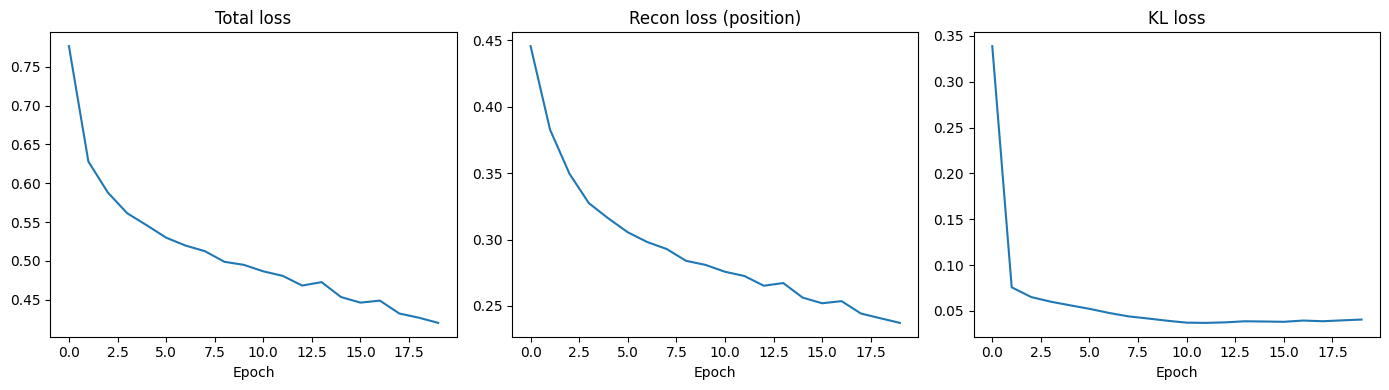

In [4]:
# TODO: Plot total, recon_pos, and KL loss curves
# YOUR CODE HERE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history['total']);     axes[0].set_title('Total loss')
axes[1].plot(history['recon_pos']); axes[1].set_title('Recon loss (position)')
axes[2].plot(history['kl']);        axes[2].set_title('KL loss')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.show()


## Step 5 -- Reconstruction grid

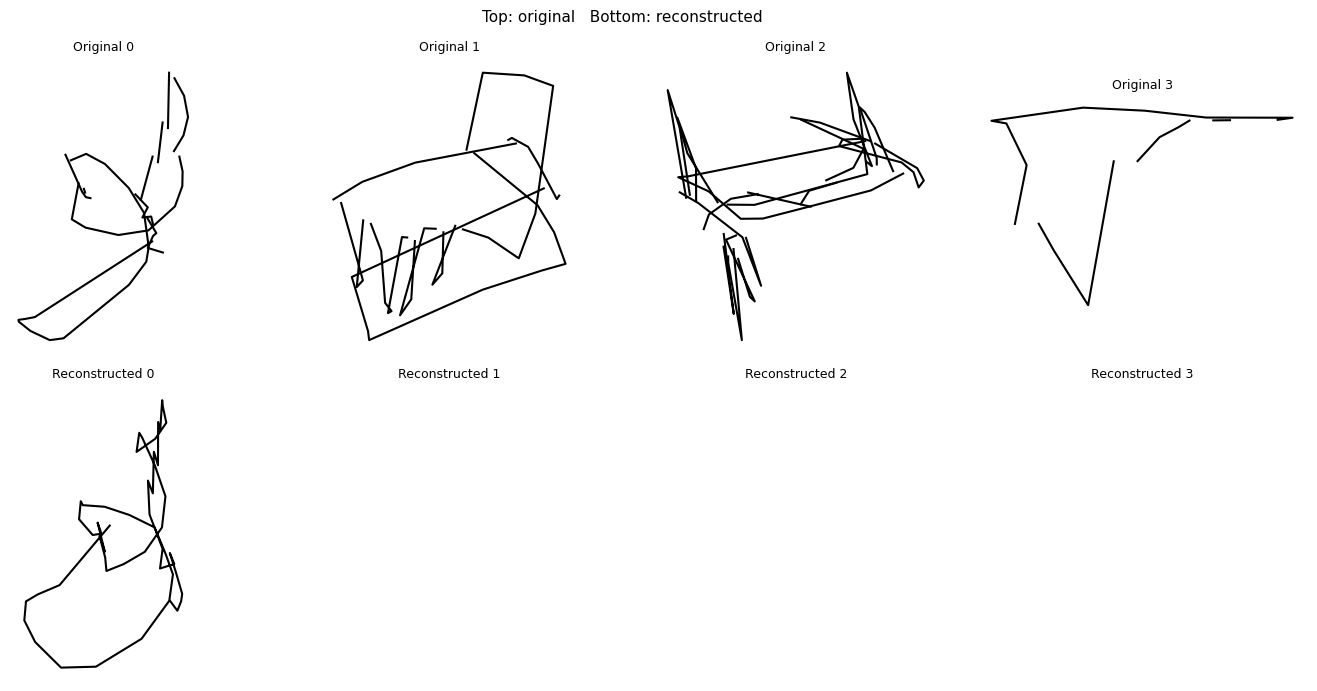

In [7]:
# TODO: Plot a 2x4 grid: top row = 4 original sketches, bottom row = reconstructions
# Use plot_sketch5 from the conductor_worker notebook
# YOUR CODE HERE
def stroke5_to_absolute(stroke5):
    abs_coords = np.cumsum(stroke5[:, :2], axis=0)
    # pen lifted where p2=1 or p3=1
    pen_up = (stroke5[:, 3] + stroke5[:, 4]) > 0.5
    return abs_coords, pen_up

def plot_sketch5(stroke5_np, title='', ax=None):
    coords, pen_up = stroke5_to_absolute(stroke5_np)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off'); ax.set_title(title, fontsize=9)
    start = 0
    for i in range(len(pen_up)):
        if pen_up[i]:
            seg = coords[start : i + 1]
            ax.plot(seg[:, 0], seg[:, 1], 'k-', linewidth=1.5)
            start = i + 1

model.eval()
with torch.no_grad():
    sample, lengths = next(iter(loader))
    sample = sample.to(device)
    recon, mu, logvar = model(sample, lengths)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    plot_sketch5(sample[i].cpu().numpy(),  title=f'Original {i}',      ax=axes[0, i])
    plot_sketch5(recon[i].cpu().numpy(),   title=f'Reconstructed {i}', ax=axes[1, i])
plt.suptitle('Top: original   Bottom: reconstructed', fontsize=11)
plt.tight_layout(); plt.show()



## Step 6 -- Reflection questions

In [8]:
# Q1: What does the Conductor add compared to the baseline VAE decoder?
#     Do your reconstructions look better or worse? Why might that be?
# The Conductor gives the Worker small instructions while drawing. This helps the
# model make better sketches.
# reconstructions look better because the model gets help throughout the drawing.

# Q2: What happens if you set num_segments=1?
#     What does this reduce the model to?
# If num_segments = 1, there is only one instruction for the whole sketch.
# It becomes similar to the basic VAE

# Q3: The Conductor produces one sub-goal vector c for every segment_len steps.
#     What does this mean if a sketch has very short strokes vs very long strokes?
# Short strokes may use the same sub-goal for only a few points. 
# long strokes use it for more points.
# So different sketches may use the sub-goals differently.

# Q4: We use cross entropy for the pen state loss instead of MSE.
#     Why is cross entropy a better choice here?
# Cross entropy is better because the pen state is a category (down, up, or end).
# MSE is better for numbers, not categories.

# YOUR ANSWERS HERE


## Bonus (optional)
- Experiment with num_segments = 8 and 32. How does it affect quality?
- Try loading the saved baseline VAE and compare reconstructions side by side with the hierarchical model on the same inputs

## Submission checklist

- [ ] Hierarchical VAE trained 20+ epochs on non-cat category
- [ ] Loss curves plotted
- [ ] 2x4 reconstruction grid
- [ ] All 4 reflection questions answered